In [2]:
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np


In [3]:
df = pd.read_parquet("../../data/model_ready/flightsweather.parquet")
df.shape

(24171385, 71)

In [4]:
df = df.dropna(subset=["tmpf",
    "vsby",
    "sknt",
    "p01i",
    "relh",
    "gust"])
df.shape

(3426007, 71)

In [5]:
df.isnull().sum().sort_values(ascending=False).head(20)

ArrDelay                106701
ArrDel15                106701
ArrivalDelayGroups      106701
ArrDelayMinutes         106701
AirTime                 106614
ActualElapsedTime       106614
WheelsOn                 99338
TaxiIn                   99338
ArrTime                  99335
WheelsOff                97568
TaxiOut                  97568
DepDel15                 95587
DepDelayMinutes          95587
DepDelay                 95587
DepartureDelayGroups     95587
DepTime                  95383
Tail_Number              19217
CRSElapsedTime               4
DivAirportLandings           1
DepTimeBlk                   0
dtype: int64

In [47]:
df.target.value_counts()

target
On time      11446007
Delayed       2816766
Cancelled      275054
Name: count, dtype: int64

In [48]:
df.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted',
       'CRSDepTime', 'DepTime', 'DepDelayMinutes', 'DepDelay', 'ArrTime',
       'ArrDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime',
       'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek',
       'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners',
       'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline',
       'Flight_Number_Marketing_Airline', 'Operating_Airline',
       'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline',
       'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID',
       'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName',
       'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac',
       'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName',
       'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepDel15',
       'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOu

In [49]:
df.target.value_counts(normalize=True)

target
On time      0.787326
Delayed      0.193754
Cancelled    0.018920
Name: proportion, dtype: float64

In [50]:
df.year.value_counts()

year
2019    4921135
2021    3741182
2018    3374909
2022    2500601
Name: count, dtype: int64

In [51]:
df.year.value_counts(normalize=True)

year
2019    0.338506
2021    0.257341
2018    0.232147
2022    0.172007
Name: proportion, dtype: float64

### Since there is a lot of data leakage in the dataset, lets only keep the columns we will know before a flight departs

In [ ]:
df = df[[
    "FlightDate",
    "Year",
    "Quarter",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "dep_hour",
    "DepTimeBlk",
    "Airline",
    "Marketing_Airline_Network",
    "Operating_Airline",
    "Origin",
    "Dest",
    "OriginState",
    "DestState",
    "Distance",
    "DistanceGroup",
    "tmpf",
    "vsby",
    "sknt",
    "p01i",
    "relh",
    "gust",
    "target"
]]


### Sampling Strategy

Another thing to consider for RF, is to sample data to not train on entire dataset.

Due to the scale of the dataset (~29M flights), we applied a multi-stage sampling strategy. 

Data were first sampled evenly across months to retain seasonal patterns. Next, the contribution of any single origin airport was capped at 5% to prevent dominance by major hubs. Finally, the sample was stratified by the target variable (on-time, delayed, cancelled) on a best-effort basis to improve class balance. This approach maintains temporal, geographic, and outcome diversity while producing a manageable dataset for baseline modeling.



In [ ]:
import pandas as pd

# -----------------------------
# CONFIG
# -----------------------------
TOTAL_SAMPLE = 600_000          # target total rows
MAX_ORIGIN_FRAC = 0.05          # no single origin >5%
RANDOM_STATE = 42

# -----------------------------
# PREP
# -----------------------------
df = df.copy()
df["FlightDate"] = pd.to_datetime(df["FlightDate"])
df["month"] = df["FlightDate"].dt.to_period("M").astype(str)

# -----------------------------
# STEP 1: BALANCE MONTHS
# -----------------------------
n_months = df["month"].nunique()
rows_per_month = TOTAL_SAMPLE // n_months

month_samples = []
for m, g in df.groupby("month"):
    month_samples.append(
        g.sample(
            n=min(len(g), rows_per_month),
            random_state=RANDOM_STATE
        )
    )

month_balanced = pd.concat(month_samples, ignore_index=True)

# -----------------------------
# STEP 2: CAP ORIGIN DOMINANCE
# -----------------------------
origin_cap = int(len(month_balanced) * MAX_ORIGIN_FRAC)

origin_balanced = (
    month_balanced
    .groupby("Origin", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=min(len(x), origin_cap),
            random_state=RANDOM_STATE
        )
    )
)

# -----------------------------
# STEP 3: STRATIFY TARGET
# -----------------------------
n_classes = origin_balanced["target"].nunique()
rows_per_class = len(origin_balanced) // n_classes

final_sample = (
    origin_balanced
    .groupby("target", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=min(len(x), rows_per_class),
            random_state=RANDOM_STATE
        )
    )
)

# -----------------------------
# FINAL CHECKS TO ENSURE TRAINING DATA REPRESENTS ENTIRE DATASET WE HAVE
# -----------------------------
print("Final rows:", len(final_sample))
print("\nTarget distribution:")
print(final_sample["target"].value_counts(normalize=True))

print("\nTop origins:")
print(final_sample["Origin"].value_counts(normalize=True).head())

print("\nMonth distribution:")
print(final_sample["month"].value_counts(normalize=True).sort_index())


Final rows: 321913

Target distribution:
target
On time      0.621264
Delayed      0.341437
Cancelled    0.037299
Name: proportion, dtype: float64

Top origins:
Origin
ORD    0.048889
ATL    0.043391
DEN    0.043099
DFW    0.036131
LAX    0.029291
Name: proportion, dtype: float64

Month distribution:
month
2018-01    0.023314
2018-02    0.023780
2018-03    0.023137
2018-04    0.022720
2018-05    0.023593
2018-06    0.024345
2018-07    0.024106
2018-08    0.024457
2018-09    0.022394
2018-10    0.022130
2018-11    0.022882
2018-12    0.022848
2019-01    0.023345
2019-02    0.023979
2019-03    0.022860
2019-04    0.023189
2019-05    0.023575
2019-06    0.024482
2019-07    0.024171
2019-08    0.024019
2019-09    0.022223
2019-10    0.022385
2019-11    0.022009
2019-12    0.023646
2021-01    0.020580
2021-02    0.022258
2021-03    0.020648
2021-04    0.020950
2021-05    0.021437
2021-06    0.024590
2021-07    0.024758
2021-08    0.024547
2021-09    0.022099
2021-10    0.023221
2021-11    0

In [ ]:
# -----------------------------
# TRAIN / VAL / TEST SPLIT
# -----------------------------
final_sample = final_sample.sort_values("FlightDate")

n = len(final_sample)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = final_sample.iloc[:train_end]
val_df   = final_sample.iloc[train_end:val_end]
test_df  = final_sample.iloc[val_end:]

# -----------------------------
# CHECKS
# -----------------------------
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain target distribution:")
print(train_df["target"].value_counts(normalize=True))

print("\nTest target distribution:")
print(test_df["target"].value_counts(normalize=True))

print("\nDate ranges:")
print("Train:", train_df["FlightDate"].min(), "→", train_df["FlightDate"].max())
print("Test :", test_df["FlightDate"].min(), "→", test_df["FlightDate"].max())


Train: (225339, 25)
Val: (48287, 25)
Test: (48287, 25)

Train target distribution:
target
On time      0.636193
Delayed      0.330258
Cancelled    0.033549
Name: proportion, dtype: float64

Test target distribution:
target
On time      0.571707
Delayed      0.381345
Cancelled    0.046948
Name: proportion, dtype: float64

Date ranges:
Train: 2018-01-01 00:00:00 → 2021-07-13 00:00:00
Test : 2022-01-24 00:00:00 → 2022-07-31 00:00:00


In [ ]:
val_df = (
    val_df
    .groupby("target", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), 50_000),
        random_state=42
    ))
)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## Random Forest Model Baseline

Features based off of EDA:
- Airline
- DeptTimeBlk
- DistanceGroup
- Month
- Dep_Hour
- Weather
- DayofWeek

In [ ]:
FEATURES = ["Quarter", "Month", "DayofMonth", "DayOfWeek", "dep_hour", "DepTimeBlk",
    "Airline", "Origin", "Dest", "Distance", "DistanceGroup",
    "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

TARGET = "target"


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split categorical vs numerical
categorical_features = [
    "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup"
]

numeric_features = [
    "Quarter", "Month", "DayofMonth", "DayOfWeek", "dep_hour",
    "Distance", "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)



In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)


In [ ]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf_model)
])


In [ ]:
# Make copies to be safe
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

# Convert categorical columns to string (needed for OneHotEncoder)
for col in categorical_features:
    train_df[col] = train_df[col].astype(str)
    val_df[col]   = val_df[col].astype(str)
    test_df[col]  = test_df[col].astype(str)

# # Fill numeric NaNs with 0
for col in numeric_features:
    train_df[col] = train_df[col].fillna(0)
    val_df[col]   = val_df[col].fillna(0)
    test_df[col]  = test_df[col].fillna(0)

# Optional: fill categorical NaNs with "missing"
for col in categorical_features:
    train_df[col] = train_df[col].fillna("missing")
    val_df[col]   = val_df[col].fillna("missing")
    test_df[col]  = test_df[col].fillna("missing")


In [ ]:
pipeline.fit(train_df[FEATURES], train_df[TARGET])


/Users/arelyvasquez/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['DepTimeBlk', 'Airline',
                                                   'Origin', 'Dest',
                                                   'DistanceGroup']),
                                                 ('num', 'passthrough',
                                                  ['Quarter', 'Month',
                                                   'DayofMonth', 'DayOfWeek',
                                                   'dep_hour', 'Distance',
                                                   'tmpf', 'vsby', 'sknt',
                                                   'p01i', 'relh', 'gust'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=15, min_samples_leaf=50,
                                        n_estimators=80, n_jobs=-1,
                                        random_state=42))])

In [ ]:
# Predictions
y_pred = pipeline.predict(test_df[FEATURES])

# Metrics
print("Classification Report:\n")
print(classification_report(test_df[TARGET], y_pred, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(test_df[TARGET], y_pred, normalize="true")
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
print("\nNormalized Confusion Matrix:\n")
print(cm_df)



Classification Report:

              precision    recall  f1-score   support

   Cancelled      0.082     0.418     0.137      2267
     Delayed      0.503     0.511     0.507     18414
     On time      0.693     0.452     0.547     27606

    accuracy                          0.473     48287
   macro avg      0.426     0.460     0.397     48287
weighted avg      0.592     0.473     0.513     48287


Normalized Confusion Matrix:

           Cancelled   Delayed   On time
Cancelled   0.417733  0.325099  0.257168
Delayed     0.220865  0.510644  0.268491
On time     0.238390  0.309244  0.452365


Test Accuracy: 0.473

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled        947      737      583
Delayed         4067     9403     4944
On time         6581     8537    12488

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled   0.417733  0.325099  0.257168
Delayed     0.220865  0.510644  0.268491
On time     0.238390  0.309244  0.452365


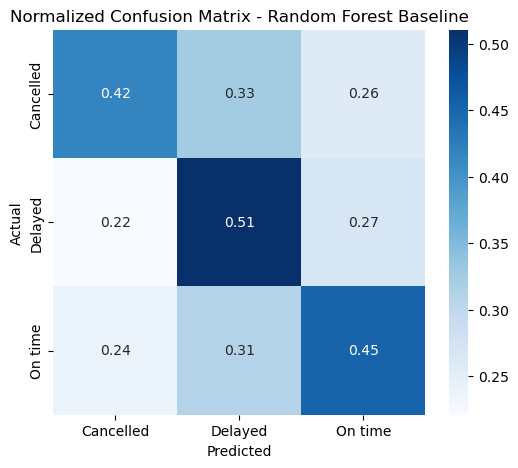


Classification Report:
              precision    recall  f1-score   support

   Cancelled      0.082     0.418     0.137      2267
     Delayed      0.503     0.511     0.507     18414
     On time      0.693     0.452     0.547     27606

    accuracy                          0.473     48287
   macro avg      0.426     0.460     0.397     48287
weighted avg      0.592     0.473     0.513     48287



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(test_df[FEATURES])
y_true = test_df[TARGET]

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))


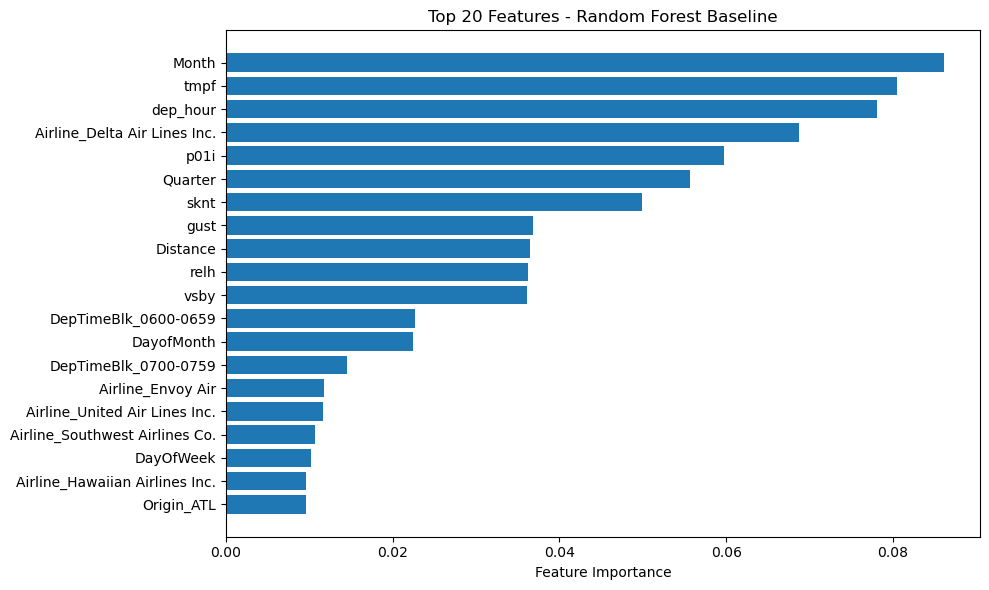

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_features = np.concatenate([cat_features, numeric_features])

# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = all_features[indices]
sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest Baseline")
plt.tight_layout()
plt.show()


In [ ]:
all_features

array(['DepTimeBlk_0001-0559', 'DepTimeBlk_0600-0659',
       'DepTimeBlk_0700-0759', 'DepTimeBlk_0800-0859',
       'DepTimeBlk_0900-0959', 'DepTimeBlk_1000-1059',
       'DepTimeBlk_1100-1159', 'DepTimeBlk_1200-1259',
       'DepTimeBlk_1300-1359', 'DepTimeBlk_1400-1459',
       'DepTimeBlk_1500-1559', 'DepTimeBlk_1600-1659',
       'DepTimeBlk_1700-1759', 'DepTimeBlk_1800-1859',
       'DepTimeBlk_1900-1959', 'DepTimeBlk_2000-2059',
       'DepTimeBlk_2100-2159', 'DepTimeBlk_2200-2259',
       'DepTimeBlk_2300-2359', 'Airline_Air Wisconsin Airlines Corp',
       'Airline_Alaska Airlines Inc.', 'Airline_Allegiant Air',
       'Airline_American Airlines Inc.', 'Airline_Cape Air',
       'Airline_Capital Cargo International', 'Airline_Comair Inc.',
       'Airline_Commutair Aka Champlain Enterprises, Inc.',
       'Airline_Compass Airlines', 'Airline_Delta Air Lines Inc.',
       'Airline_Empire Airlines Inc.', 'Airline_Endeavor Air Inc.',
       'Airline_Envoy Air', 'Airline_ExpressJe

### Now let's do a more simple Random Forest Model

In [ ]:
train_df[FEATURES].head()

,Quarter,Month,DayofMonth,DayOfWeek,dep_hour,DepTimeBlk,Airline,Origin,Dest,Distance,DistanceGroup,tmpf,vsby,sknt,p01i,relh,gust
2240,1,1,1,1,18,1800-1859,Alaska Airlines Inc.,ONT,SEA,956.0,4,0.0,0.000000,0.000000,0.0,0.00,0.0
11752,1,1,1,1,14,1400-1459,Southwest Airlines Co.,BWI,BHM,682.0,3,18.0,10.000000,3.384615,0.0,61.52,0.0
11020,1,1,1,1,8,0800-0859,Delta Air Lines Inc.,AUS,SLC,1086.0,5,26.1,10.000000,16.500000,0.0,71.04,23.0
11478,1,1,1,1,15,1500-1559,SkyWest Airlines Inc.,SEA,PDX,129.0,1,32.0,9.153846,8.846154,0.0,84.98,0.0
2738,1,1,1,1,21,2100-2159,Delta Air Lines Inc.,ATL,DCA,547.0,3,27.0,10.000000,10.923077,0.0,48.20,16.0


In [ ]:
df.tmpf.isna().sum()/df.shape[0]

0.3984933010665297